<a href="https://colab.research.google.com/github/shoxruxmamitov/kichik-loiha/blob/main/car_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
!wget clone https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv

--2026-03-28 13:06:35--  http://clone/
Resolving clone (clone)... failed: Name or service not known.
wget: unable to resolve host address ‘clone’
--2026-03-28 13:06:36--  https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21222 (21K) [text/plain]
Saving to: ‘mpg.csv’

mpg.csv             100%[===================>]  20.72K  --.-KB/s    in 0.001s  

2026-03-28 13:06:36 (17.1 MB/s) - ‘mpg.csv’ saved [21222/21222]

FINISHED --2026-03-28 13:06:36--
Total wall clock time: 0.3s
Downloaded: 1 files, 21K in 0.001s (17.1 MB/s)


In [7]:
df = pd.read_csv('mpg.csv')
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [10]:
df.shape # bizda 398 ta qator 9 ta ustun bor

(398, 9)

In [23]:
df.size # 3582 ta qimat bor

3582

In [22]:
df.info() # data ni malumotlarini aniqlab oldik

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [20]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [25]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [24]:
df.drop('name', axis=1, inplace=True)
df # bizda keraksiz ustun bor uni olib tashladik 'name' ustuni

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa
394,44.0,4,97.0,52.0,2130,24.6,82,europe
395,32.0,4,135.0,84.0,2295,11.6,82,usa
396,28.0,4,120.0,79.0,2625,18.6,82,usa


In [42]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.isnull().sum() # horsepowerda nan qimat mavjud 6 ta

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


In [45]:
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)
df.isnull().sum() # horsepower nan qimatlarni ornini toldirib chiqdik

/tmp/ipykernel_682/262152805.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0


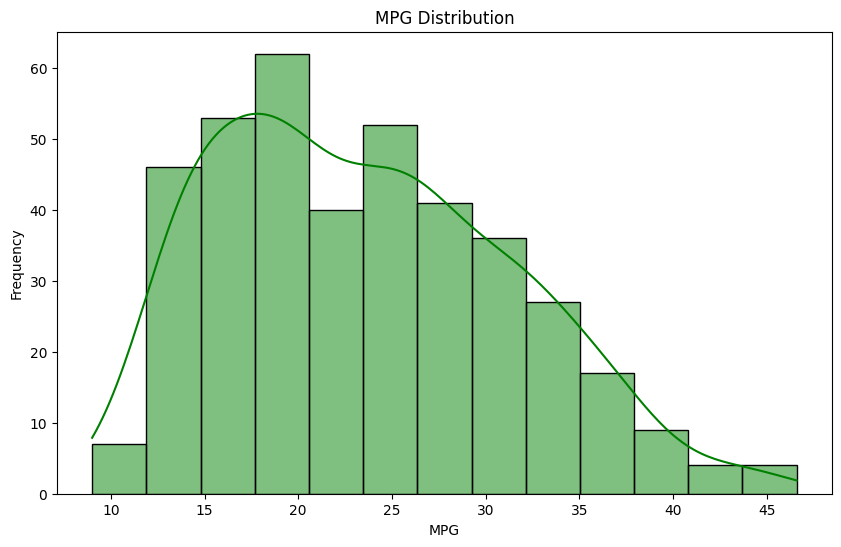

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(df['mpg'], kde=True, color='green')
plt.title('MPG Distribution')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

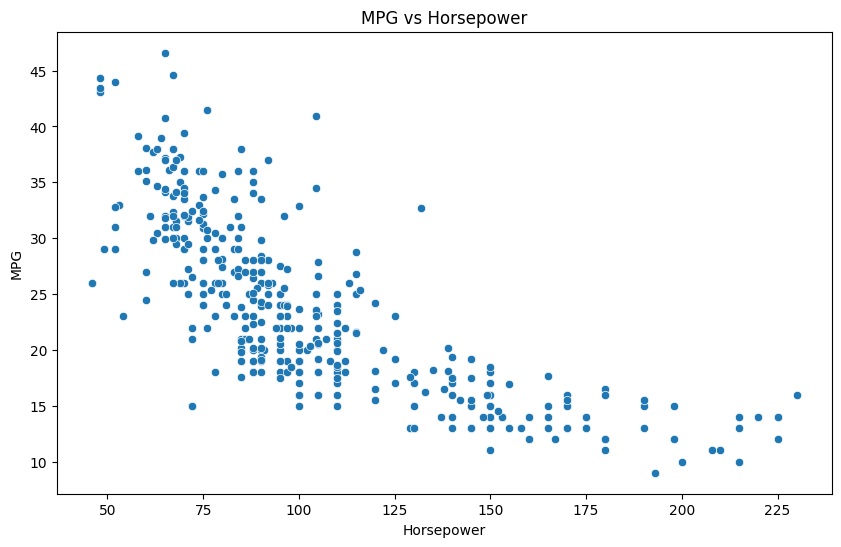

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title('MPG vs Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()

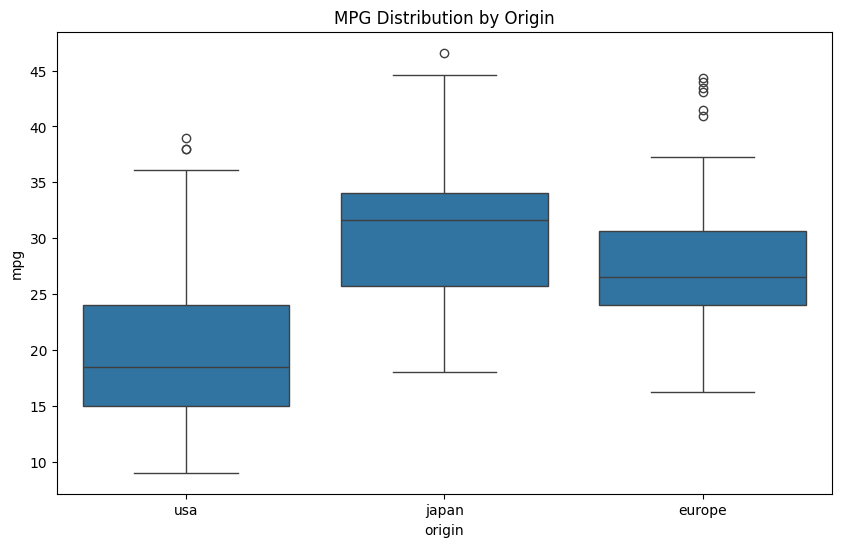

In [50]:
plt.figure(figsize=(10, 6))
plt.title('MPG Distribution by Origin')
sns.boxplot(x='origin', y='mpg', data=df)
plt.show()

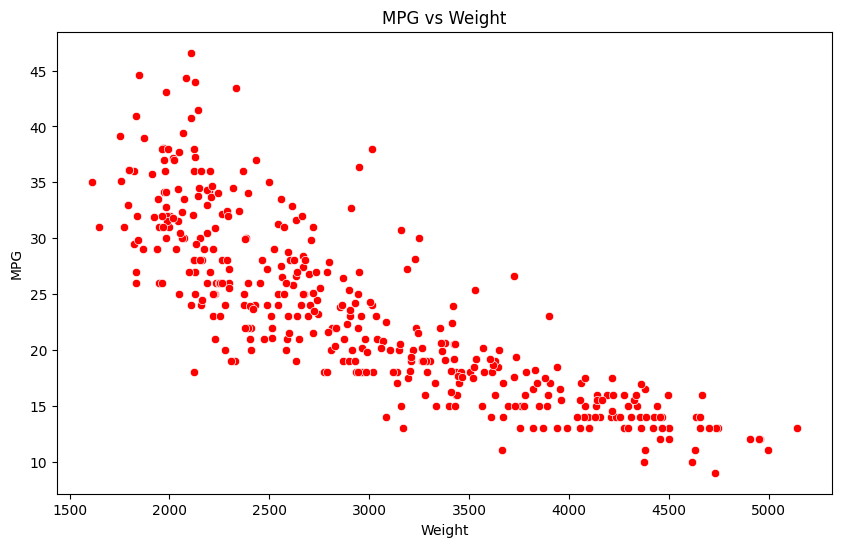

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight', y='mpg', color='r', data=df)
plt.title('MPG vs Weight')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

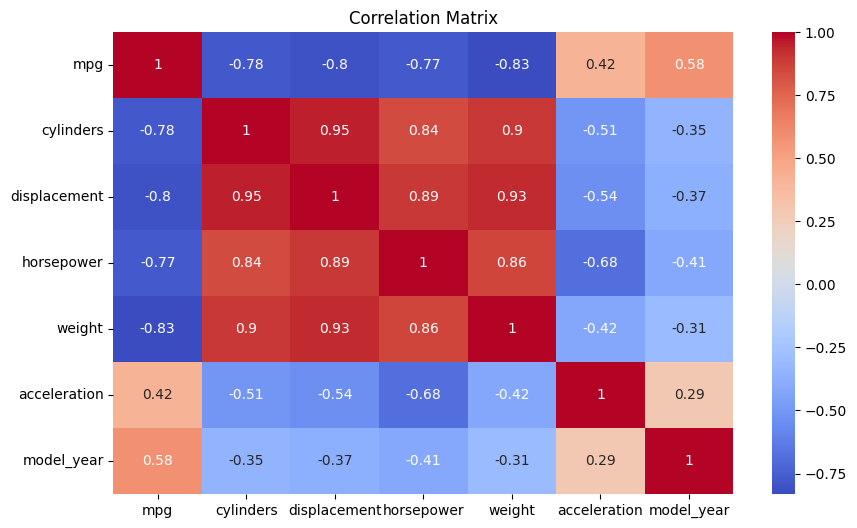

In [65]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

<Figure size 1600x800 with 0 Axes>

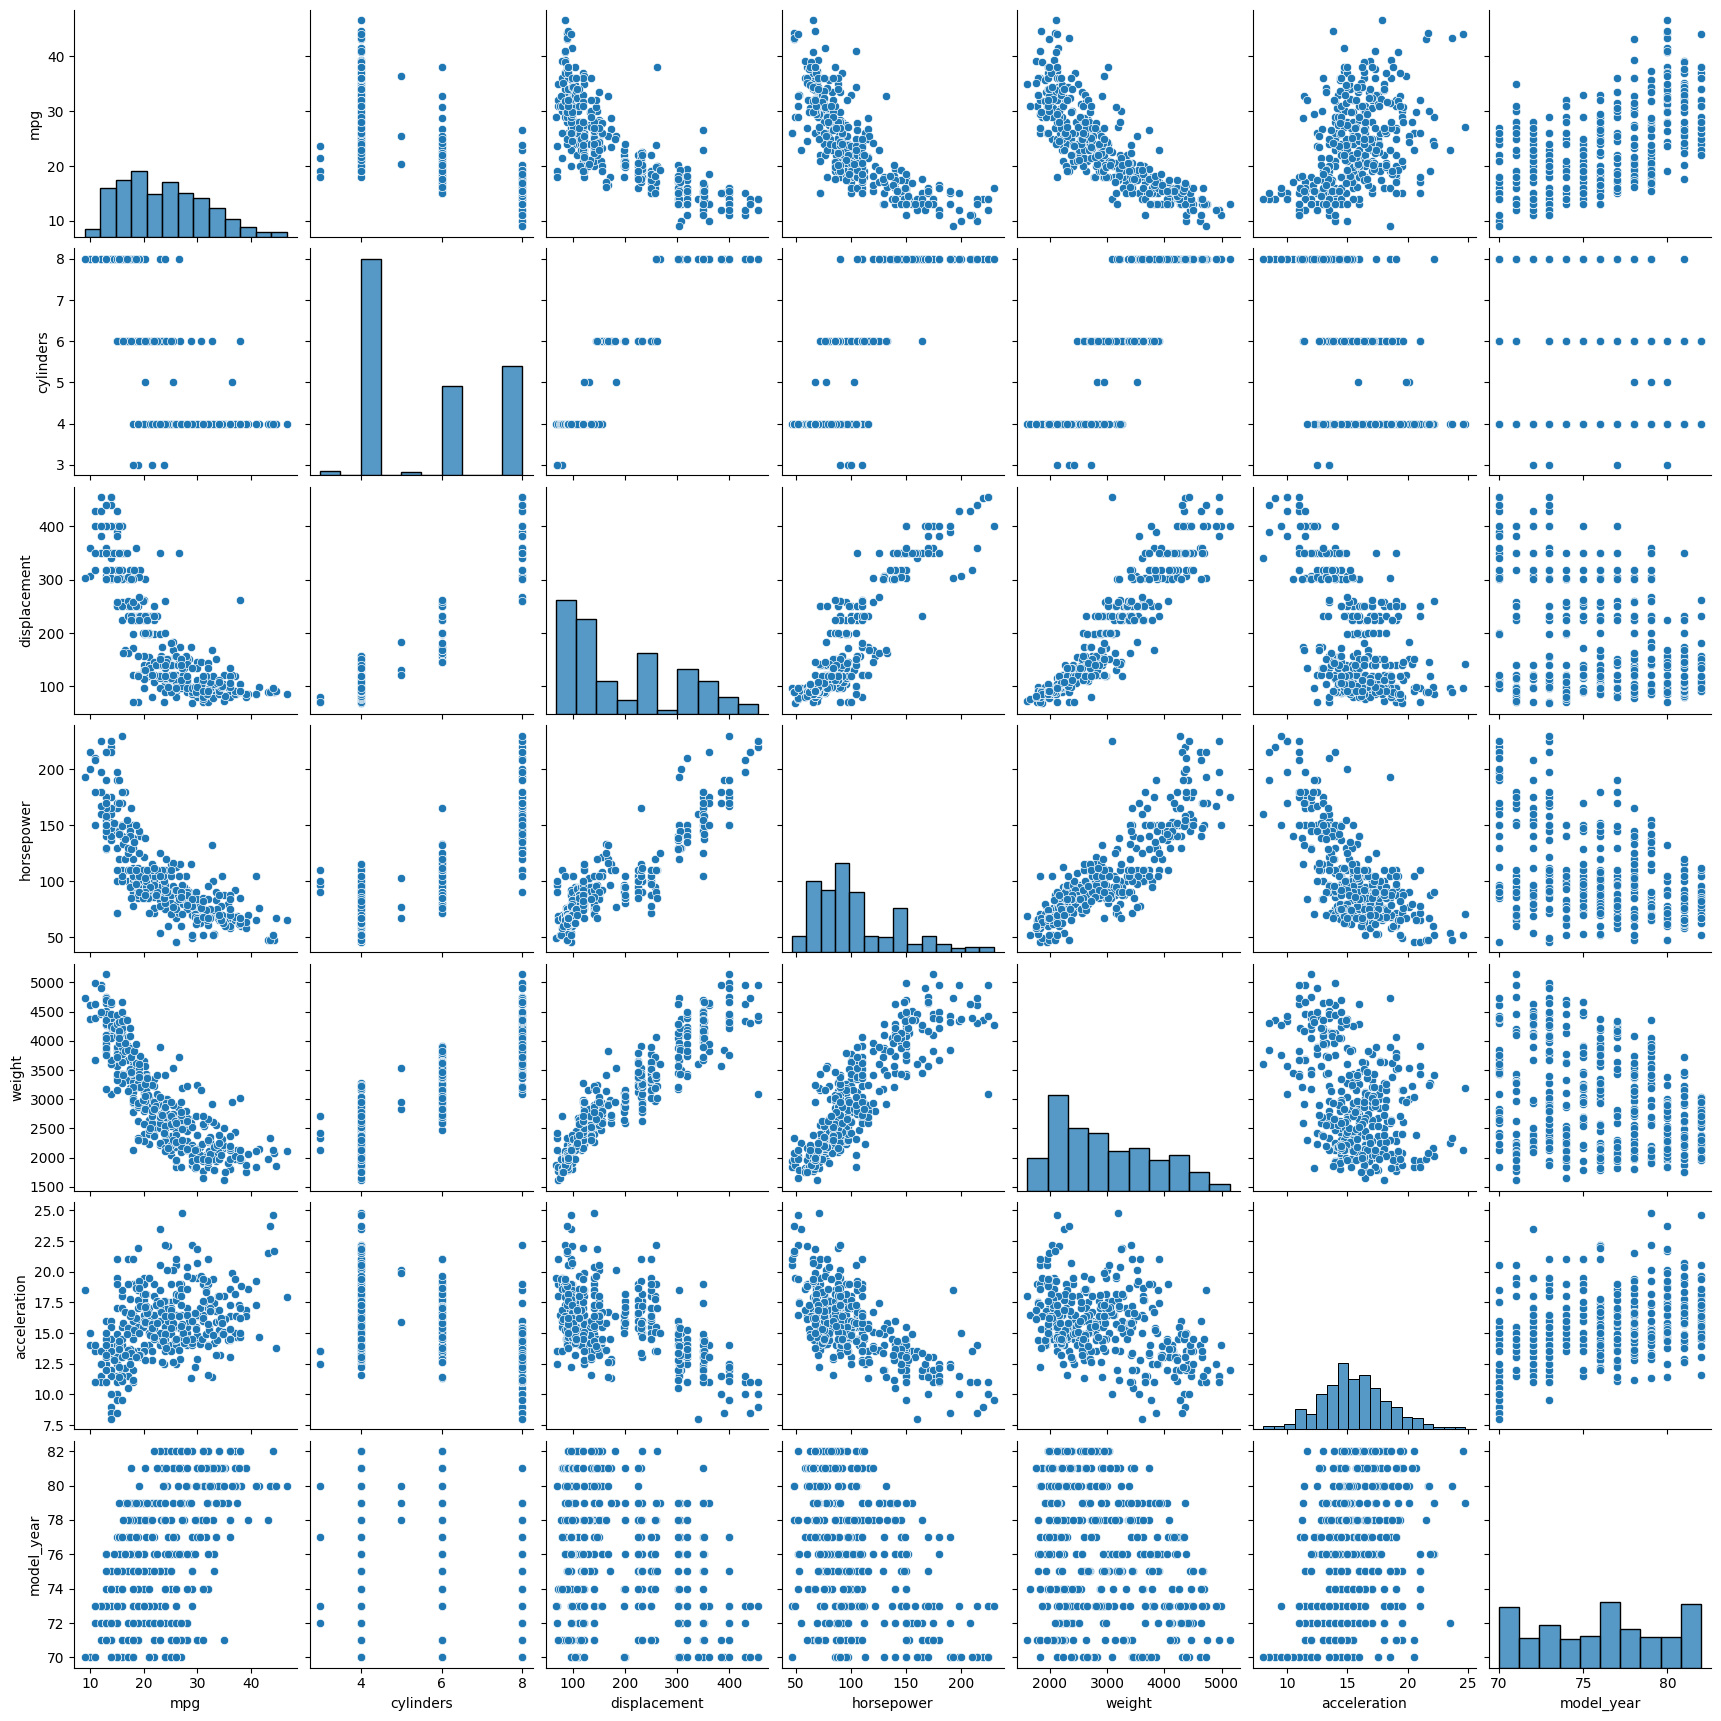

In [82]:
plt.figure(figsize=(16, 8))
sns.pairplot(df.select_dtypes(include=[np.number]))
plt.show()
# amaliot uchun

In [73]:
df.sort_values(by='mpg', ascending=False).head(10)
# tejamkor moshinalr top 10 taligi

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
322,46.6,4,86.0,65.000000,2110,17.9,80,japan
329,44.6,4,91.0,67.000000,1850,13.8,80,japan
325,44.3,4,90.0,48.000000,2085,21.7,80,europe
394,44.0,4,97.0,52.000000,2130,24.6,82,europe
326,43.4,4,90.0,48.000000,2335,23.7,80,europe
244,43.1,4,90.0,48.000000,1985,21.5,78,europe
309,41.5,4,98.0,76.000000,2144,14.7,80,europe
330,40.9,4,85.0,104.469388,1835,17.3,80,europe
324,40.8,4,85.0,65.000000,2110,19.2,80,japan
247,39.4,4,85.0,70.000000,2070,18.6,78,japan


In [75]:
df.sort_values(by='mpg').head(10)
# kop yoqilgi yeydigan 10 ta moshina

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
28,9.0,8,304.0,193.0,4732,18.5,70,usa
25,10.0,8,360.0,215.0,4615,14.0,70,usa
26,10.0,8,307.0,200.0,4376,15.0,70,usa
67,11.0,8,429.0,208.0,4633,11.0,72,usa
27,11.0,8,318.0,210.0,4382,13.5,70,usa
103,11.0,8,400.0,150.0,4997,14.0,73,usa
124,11.0,8,350.0,180.0,3664,11.0,73,usa
42,12.0,8,383.0,180.0,4955,11.5,71,usa
95,12.0,8,455.0,225.0,4951,11.0,73,usa
104,12.0,8,400.0,167.0,4906,12.5,73,usa


In [85]:
df.groupby('origin')['mpg'].mean()
# qasi davlat moshinalari tejamkor

,mpg
origin,
europe,27.891429
japan,30.450633
usa,20.083534


In [86]:
df.groupby('origin')['mpg'].median()
# usa eng ko'p yoqilgi yeydi
# europo ortacha yoqilgi yeydi
# japan eng tejamkori

,mpg
origin,
europe,26.5
japan,31.6
usa,18.5


In [87]:
df.groupby(pd.cut(df['horsepower'], bins=5))['mpg'].mean()
# past horsepower bn yuqori horsepower ning farqi

/tmp/ipykernel_682/1473948580.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['horsepower'], bins=5))['mpg'].mean()


,mpg
horsepower,
"(45.816, 82.8]",31.303279
"(82.8, 119.6]",23.197647
"(119.6, 156.4]",16.060606
"(156.4, 193.2]",13.711111
"(193.2, 230.0]",12.769231


In [80]:
df.groupby(pd.cut(df['weight'], bins=5))['mpg'].mean()
# past weight bn yuqori weight ning farqi

/tmp/ipykernel_682/1754711320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['weight'], bins=5))['mpg'].mean()


,mpg
weight,
"(1609.473, 2318.4]",31.337190
"(2318.4, 3023.8]",25.138938
"(3023.8, 3729.2]",19.068831
"(3729.2, 4434.6]",15.095238
"(4434.6, 5140.0]",12.791667


In [91]:
df.sort_values('origin', inplace=True)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
117,29.0,4,68.0,49.0,1867,19.5,73,europe
142,26.0,4,79.0,67.0,1963,15.5,74,europe
143,26.0,4,97.0,78.0,2300,14.5,74,europe
293,31.9,4,89.0,71.0,1925,14.0,79,europe
147,24.0,4,90.0,75.0,2108,15.5,74,europe
...,...,...,...,...,...,...,...,...
152,19.0,6,225.0,95.0,3264,16.0,75,usa
146,28.0,4,90.0,75.0,2125,14.5,74,usa
140,14.0,8,304.0,150.0,4257,15.5,74,usa
169,20.0,6,232.0,100.0,2914,16.0,75,usa


In [92]:
df.to_csv('car-analysis.csv', index=False)